In [1]:
import pandas as pd
import sys
import os

sys.path.append("../../..")
from typing import Optional, Union
import yaml

import autoslo.utils.paths as pu

pd.set_option("display.max_columns", None)


def process_one(run_id: Union[str, int]) -> Optional[pd.DataFrame]:
    run_params_path = os.path.join(pu.get_data_path(), "runs", str(run_id), "run_params.yml")
    
    conn_info_path = os.path.join(pu.AUTOSLO_ROOT, "config", "conn.yml")

    # Check file existence and read them in.
    if (
        not os.path.exists(run_params_path)
        or not os.path.exists(conn_info_path)
    ):
        print(f"Missing files for run_id {run_id}")
        return None
    with open(run_params_path, "r") as f:
        run_params = yaml.safe_load(f)
    with open(conn_info_path, "r") as f:
        conn_info = yaml.safe_load(f)
    endpoint_name = run_params["endpoint_name"]
    if endpoint_name not in conn_info["endpoints"]:
        print(f"Endpoint {endpoint_name} not found in connection info.")
        return None
    endpoint_rpu = conn_info["endpoints"][endpoint_name]["rpu"]

    sys_query_history_path = os.path.join(
        pu.get_data_path(), "runs", str(run_id), f"sys_query_history+cluster_{endpoint_rpu}.parquet"
    )
    sys_query_history = pd.read_parquet(sys_query_history_path)

    if run_params['trace_path'] != '/home/markakis/autoslo/data/benchmarking_traces/benchmarking_trace_99_3_3_shuffled_42.parquet':
        return None

    # Process columns as needed.
    assert all(
        sys_query_history["result_cache_hit"] == False
    ), "Expected all cache misses"
    sys_query_history["full_internal_query_id"] = sys_query_history["query_text"].apply(
        lambda x: x.split("\\n")[0][3:]
    )
    sys_query_history[
        ["run_id", "run_query_count", "tpcds_template_id", "tpcds_query_in_template"]
    ] = sys_query_history["full_internal_query_id"].str.split("/", expand=True)
    sys_query_history["run_id"] = sys_query_history["run_id"].astype(int)
    sys_query_history["run_query_count"] = sys_query_history["run_query_count"].astype(
        int
    )
    sys_query_history["tpcds_template_id"] = sys_query_history[
        "tpcds_template_id"
    ].astype(int)
    sys_query_history["tpcds_query_in_template"] = sys_query_history[
        "tpcds_query_in_template"
    ].astype(int)
    sys_query_history["endpoint_name"] = endpoint_name
    sys_query_history["endpoint_rpu"] = endpoint_rpu

    # Convert all the columns ending in "_time" from microseconds to seconds and append "_s" to their names.
    US_IN_S = 1_000_000
    time_columns = [
        col
        for col in sys_query_history.columns
        if col.endswith("_time") and col not in ["start_time", "end_time"]
    ]
    for col in time_columns:
        sys_query_history[col] = sys_query_history[col] / US_IN_S
        sys_query_history.rename(columns={col: f"{col}_s"}, inplace=True)

    # Filter/order useful columns
    column_list = [
        "run_id",
        "run_query_count",
        "tpcds_template_id",
        "tpcds_query_in_template",
        "endpoint_name",
        "endpoint_rpu",
        "start_time",
        "end_time",
        "elapsed_time_s",
        "queue_time_s",
        "execution_time_s",
        "compile_time_s",
        "planning_time_s",
        "lock_wait_time_s",
    ]
    filtered = sys_query_history[column_list]

    return filtered

def process_all() -> pd.DataFrame:
    all_dfs = []
    runs_dir = os.path.join(pu.get_data_path(), "runs")
    for run_id in os.listdir(runs_dir):
        df = process_one(run_id)
        if df is not None:
            all_dfs.append(df)
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()


df = process_all()
df

KeyError: 'endpoint_name'

In [3]:
# Calculate the coefficient of variation in elapsed time, grouping per endpoint and query template.
cv_df = (
    df.groupby(["endpoint_name", "tpcds_template_id"])
    .agg(
        count=("elapsed_time_s", "count"),
        mean_elapsed_time=("elapsed_time_s", "mean"),
        std_elapsed_time=("elapsed_time_s", "std"),
    )
    .reset_index()
)
cv_df["cv_elapsed_time_s"] = cv_df["std_elapsed_time"] / cv_df["mean_elapsed_time"]
cv_df = cv_df.sort_values(by="cv_elapsed_time_s", ascending=False)
cv_df

,endpoint_name,tpcds_template_id,count,mean_elapsed_time,std_elapsed_time,cv_elapsed_time_s
599,8,6,9,2.066871,4.944234,2.392135
651,8,58,9,2.736854,6.383473,2.332413
283,256,86,9,0.639457,1.409639,2.204431
613,8,20,9,2.014861,4.397077,2.182323
676,8,83,9,2.934904,6.375366,2.172257
...,...,...,...,...,...,...
293,256,96,9,0.210009,0.002799,0.013330
383,32,87,9,6.086752,0.079388,0.013043
300,32,4,9,19.819155,0.242856,0.012254
95,128,96,9,0.312049,0.002543,0.008150


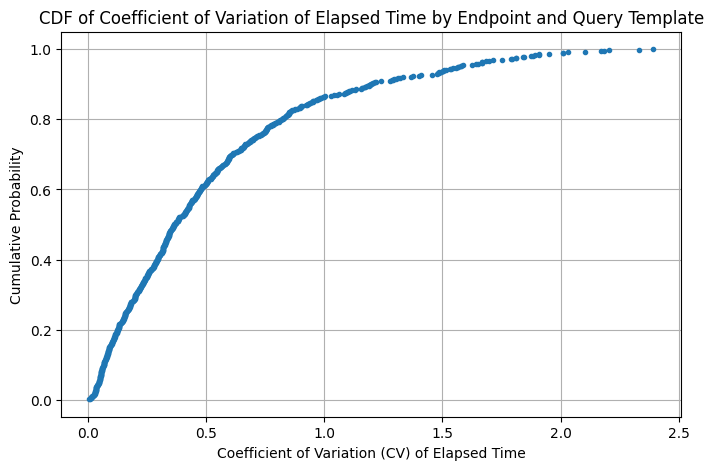

In [4]:
# Plot the cdf of cvs
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
sorted_cvs = np.sort(cv_df["cv_elapsed_time_s"].dropna())
cdf = np.arange(1, len(sorted_cvs) + 1) / len(sorted_cvs)
plt.plot(sorted_cvs, cdf, marker='.', linestyle='none')
plt.xlabel('Coefficient of Variation (CV) of Elapsed Time')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Coefficient of Variation of Elapsed Time by Endpoint and Query Template')
plt.grid(True)
plt.show()

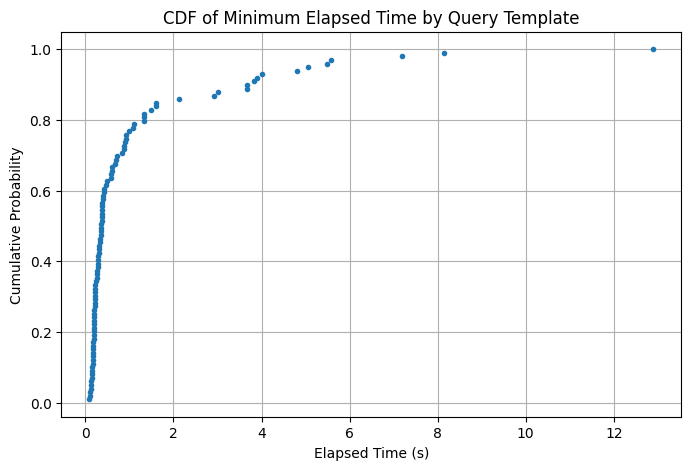

In [5]:
# Plot a cdf that says the following: For a value of time x, what percentage of query templates are always slower than x in every execution we saw?
import matplotlib.pyplot as plt
import numpy as np

# For each query template, get the min elapsed time across all endpoints and runs.
min_times = df.groupby('tpcds_template_id')['elapsed_time_s'].min().reset_index()

plt.figure(figsize=(8, 5))
sorted_min_times = np.sort(min_times['elapsed_time_s'])
cdf = np.arange(1, len(sorted_min_times) + 1) / len(sorted_min_times)
plt.plot(sorted_min_times, cdf, marker='.', linestyle='none')
plt.xlabel('Elapsed Time (s)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Minimum Elapsed Time by Query Template')
plt.grid(True)
plt.show()

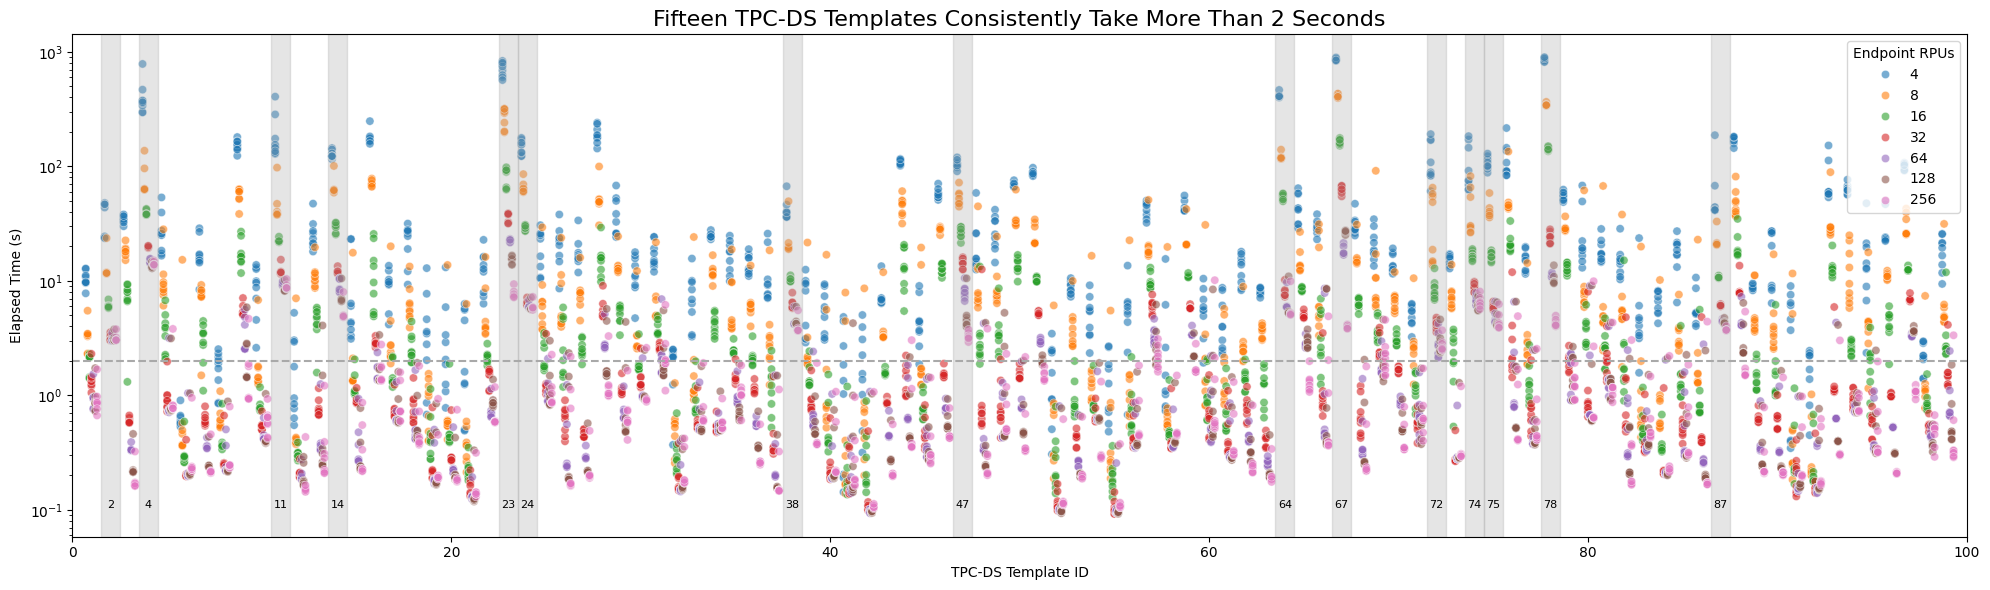

In [6]:
# Plot a grouped scatter plot, where the y axis is elapsed time in log scale. The x axis is the query template id. For each x axis value, there is a point for the mean of each endpoint, with different colors.
# Cast the endpoint names as integers and set the palette accordingly to get darker colors for higher rpu values.
import seaborn as sns
fig, ax = plt.subplots(figsize=(20, 6))

possible_rpus = sorted(df['endpoint_rpu'].unique())
rpu_to_int = {rpu: i for i, rpu in enumerate(possible_rpus)}


df['xpos'] = df['tpcds_template_id'] + df['endpoint_rpu'].map(rpu_to_int) * 0.1 - (len(possible_rpus) - 1) * 0.1 / 2


# Make sure to pick a palette with distinctive enough colors.
sns.scatterplot(
    data=df.sort_values(by="endpoint_rpu"),
    x="xpos",
    y="elapsed_time_s",
    hue="endpoint_name",
    alpha=0.6,
    ax=ax,

)

# Draw a horizontal line at 2 seconds
ax.axhline(2, color='darkgray', linestyle='--')

# For each template where all executions are above 2 seconds, shade its area in light red. Also write the template id at the bottom of the shaded area/
templates_above_2s = df.groupby('tpcds_template_id').filter(lambda x: (x['elapsed_time_s'] > 2).all())['tpcds_template_id'].unique()
for template_id in templates_above_2s:
    ax.axvspan(template_id - 0.5, template_id + 0.5, color='darkgray', alpha=0.3)
    ax.text(template_id, 0.1, str(template_id), color='black', ha='center', va='bottom', fontsize=8)

ax.set_yscale("log")
ax.set_xlim(df['tpcds_template_id'].min() - 1, df['tpcds_template_id'].max() + 1)
ax.set_ylabel("Elapsed Time (s)")
ax.set_xlabel("TPC-DS Template ID")
ax.set_title("Fifteen TPC-DS Templates Consistently Take More Than 2 Seconds", fontsize=16)
ax.legend(title="Endpoint RPUs", loc='upper right')
plt.tight_layout()
plt.savefig("heavy_hitters_scatter.png", dpi=300)
plt.show()

In [7]:
# Save out the processed dataframe for future use.
df['heavy_hitter'] = df['tpcds_template_id'].isin(templates_above_2s)
df.to_parquet(os.path.join(pu.DATA_PATH, "query_history_processed.parquet"))

with open(os.path.join(pu.DATA_PATH, "heavy_templates.txt"), "w") as f:
    for template_id in sorted(templates_above_2s):
        f.write(f"{template_id}\n")

In [2]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette, set_plot_colors
import os
import seaborn as sns
import pandas as pd

from autoslo.workload_execution.trace import Trace


run_ids = sorted(pu.RunLocator.get_run_ids(workload_name='99_3_3', schema_name='ext'))[:-1]

dfs = []

for run_id in run_ids:
    trace = Trace(run_id)
    latencies = trace.latencies_s
    tpcds_temp_and_q_idxs = trace.tpcds_temp_and_q_idxs

    df = latencies.to_frame(name='latency_s').merge(
        tpcds_temp_and_q_idxs.to_frame(name='tpcds_template_and_query_idx'),
        left_index=True,
        right_index=True,
    )
    
    df[['tpcds_template_id','tpcds_q_idx']] = df['tpcds_template_and_query_idx'].apply(lambda x: [int(a) for a in x.split('_')]).tolist()
    df['run_id'] = run_id
    df['rpu'] = list(trace.rpu_per_cluster().values())[0]
    dfs.append(df)
full_df = pd.concat(dfs, ignore_index=True)
full_df['endpoint_name'] = full_df['rpu'].apply(str)

In [3]:
full_df

,latency_s,tpcds_template_and_query_idx,tpcds_template_id,tpcds_q_idx,run_id,rpu,endpoint_name
0,5.592404,086_003,86,3,1759156767,16,16
1,15.105115,082_001,82,1,1759156767,16,16
2,11.859022,099_001,99,1,1759156767,16,16
3,1.881556,020_002,20,2,1759156767,16,16
4,34.731367,088_001,88,1,1759156767,16,16
...,...,...,...,...,...,...,...
6232,1.238487,032_001,32,1,1759429111,4,4
6233,13.181634,085_002,85,2,1759429111,4,4
6234,35.016537,003_003,3,3,1759429111,4,4
6235,18.010481,013_003,13,3,1759429111,4,4


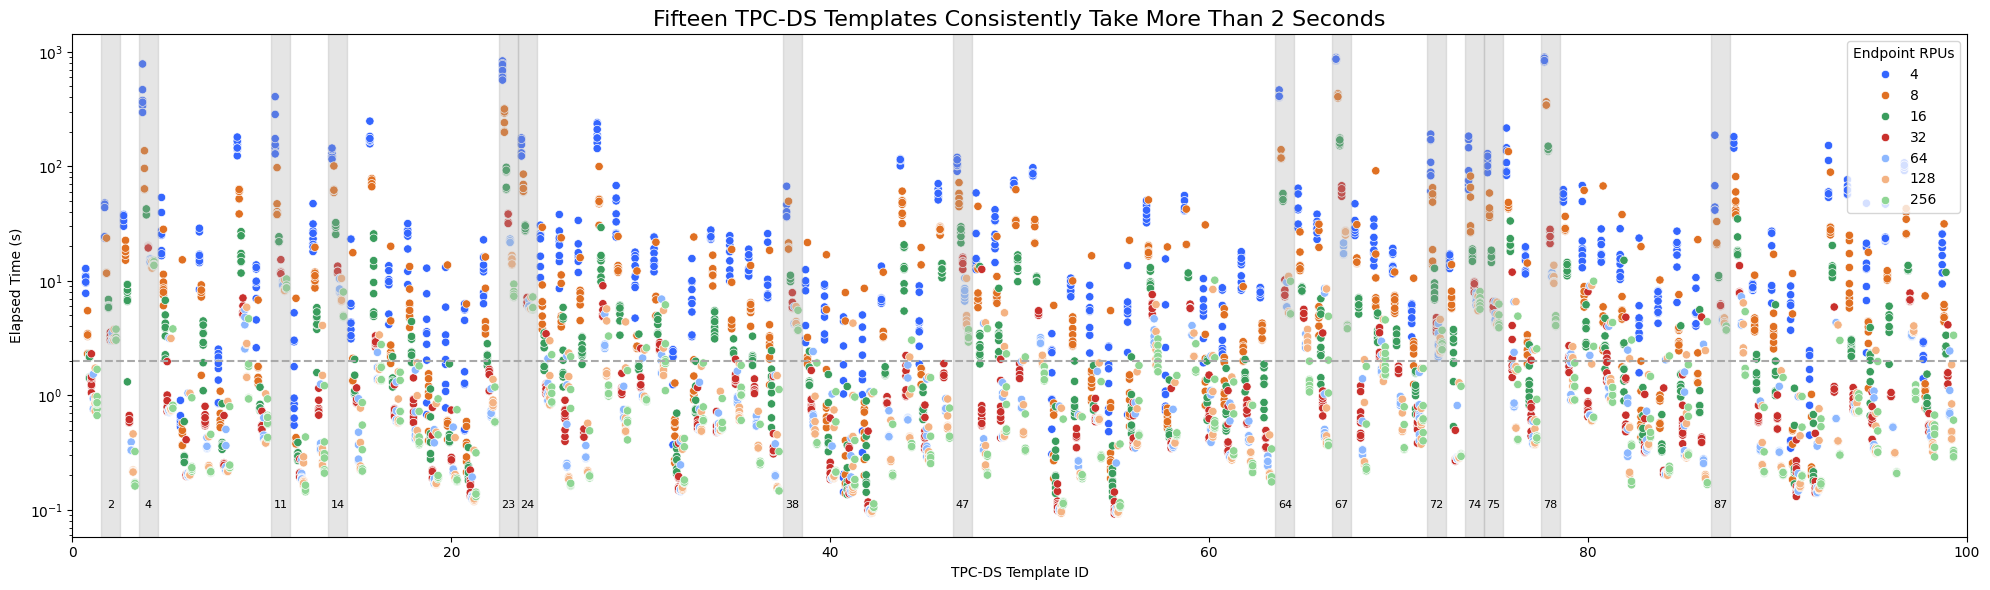

In [4]:
# Plot a grouped scatter plot, where the y axis is elapsed time in log scale. The x axis is the query template id. For each x axis value, there is a point for the mean of each endpoint, with different colors.
# Cast the endpoint names as integers and set the palette accordingly to get darker colors for higher rpu values.
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 6))

possible_rpus = sorted(full_df['rpu'].unique())
rpu_to_int = {rpu: i for i, rpu in enumerate(possible_rpus)}


full_df['xpos'] = full_df['tpcds_template_id'] + full_df['rpu'].map(rpu_to_int) * 0.1 - (len(possible_rpus) - 1) * 0.1 / 2

num_unique_rpu = full_df['rpu'].nunique()
colors = Palette.as_list()[:num_unique_rpu]



# Make sure to pick a palette with distinctive enough colors.
sns.scatterplot(
    data=full_df.sort_values(by="rpu"),
    x="xpos",
    y="latency_s",
    hue="endpoint_name",
    ax=ax,
    palette=colors
)

# Draw a horizontal line at 2 seconds
ax.axhline(2, color='darkgray', linestyle='--')

# For each template where all executions are above 2 seconds, shade its area in light red. Also write the template id at the bottom of the shaded area/
templates_above_2s = full_df.groupby('tpcds_template_id').filter(lambda x: (x['latency_s'] > 2).all())['tpcds_template_id'].unique()
for template_id in templates_above_2s:
    ax.axvspan(template_id - 0.5, template_id + 0.5, color='darkgray', alpha=0.3)
    ax.text(template_id, 0.1, str(template_id), color='black', ha='center', va='bottom', fontsize=8)

ax.set_yscale("log")
ax.set_xlim(full_df['tpcds_template_id'].min() - 1, full_df['tpcds_template_id'].max() + 1)
ax.set_ylabel("Elapsed Time (s)")
ax.set_xlabel("TPC-DS Template ID")
ax.set_title("Fifteen TPC-DS Templates Consistently Take More Than 2 Seconds", fontsize=16)
ax.legend(title="Endpoint RPUs", loc='upper right')
plt.tight_layout()
plt.savefig("heavy_hitters_scatter_2.svg", dpi=300)
plt.show()

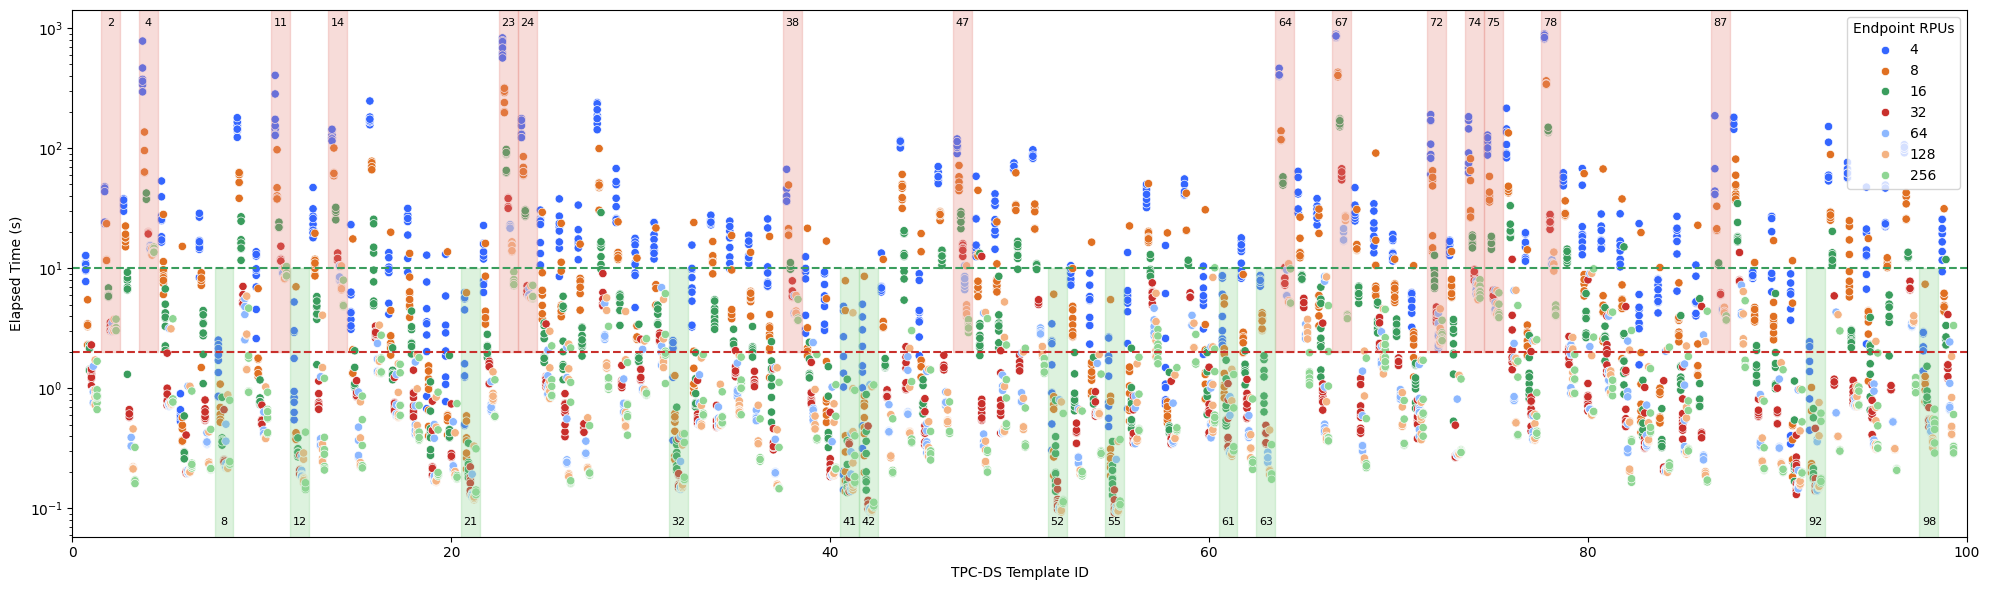

In [5]:
# Plot a grouped scatter plot, where the y axis is elapsed time in log scale. The x axis is the query template id. For each x axis value, there is a point for the mean of each endpoint, with different colors.
# Cast the endpoint names as integers and set the palette accordingly to get darker colors for higher rpu values.
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(20, 6))

possible_rpus = sorted(full_df['rpu'].unique())
rpu_to_int = {rpu: i for i, rpu in enumerate(possible_rpus)}


full_df['xpos'] = full_df['tpcds_template_id'] + full_df['rpu'].map(rpu_to_int) * 0.1 - (len(possible_rpus) - 1) * 0.1 / 2

num_unique_rpu = full_df['rpu'].nunique()
colors = Palette.as_list()[:num_unique_rpu]



# Make sure to pick a palette with distinctive enough colors.
sns.scatterplot(
    data=full_df.sort_values(by="rpu"),
    x="xpos",
    y="latency_s",
    hue="endpoint_name",
    ax=ax,
    palette=colors
)
ax.set_yscale("log")
ax.set_xlim(full_df['tpcds_template_id'].min() - 1, full_df['tpcds_template_id'].max() + 1)


# Draw a horizontal line at 2 seconds
ax.axhline(2, color=Palette.dark_red, linestyle='--')


# For each template where all executions are above 2 seconds, shade its area in light red. Also write the template id at the bottom of the shaded area/
templates_above_2s = full_df.groupby('tpcds_template_id').filter(lambda x: (x['latency_s'] > 2).all())['tpcds_template_id'].unique()
for template_id in templates_above_2s:
    
    ax.add_patch(Rectangle((template_id - 0.5, 2), 1, ax.get_ylim()[1], color=Palette.light_red, alpha=0.3))
    ax.text(template_id, 1000, str(template_id), color='black', ha='center', va='bottom', fontsize=8)

# Draw a horizontal line at 10 seconds
ax.axhline(10, color=Palette.dark_green, linestyle='--')

# For each template where all executions are below 10 seconds, shade its area in light red. Also write the template id at the bottom of the shaded area/
templates_below_10s = full_df.groupby('tpcds_template_id').filter(lambda x: (x['latency_s'] < 10).all())['tpcds_template_id'].unique()
for template_id in templates_below_10s:
    ax.add_patch(Rectangle((template_id - 0.5, 0), 1, 10, color=Palette.light_green, alpha=0.3))
    ax.text(template_id, 0.07, str(template_id), color='black', ha='center', va='bottom', fontsize=8)


ax.set_ylabel("Elapsed Time (s)")
ax.set_xlabel("TPC-DS Template ID")
ax.legend(title="Endpoint RPUs", loc='upper right')
plt.tight_layout()
plt.savefig("heavy_hitters_scatter_3.svg", dpi=300, bbox_inches='tight')
plt.show()

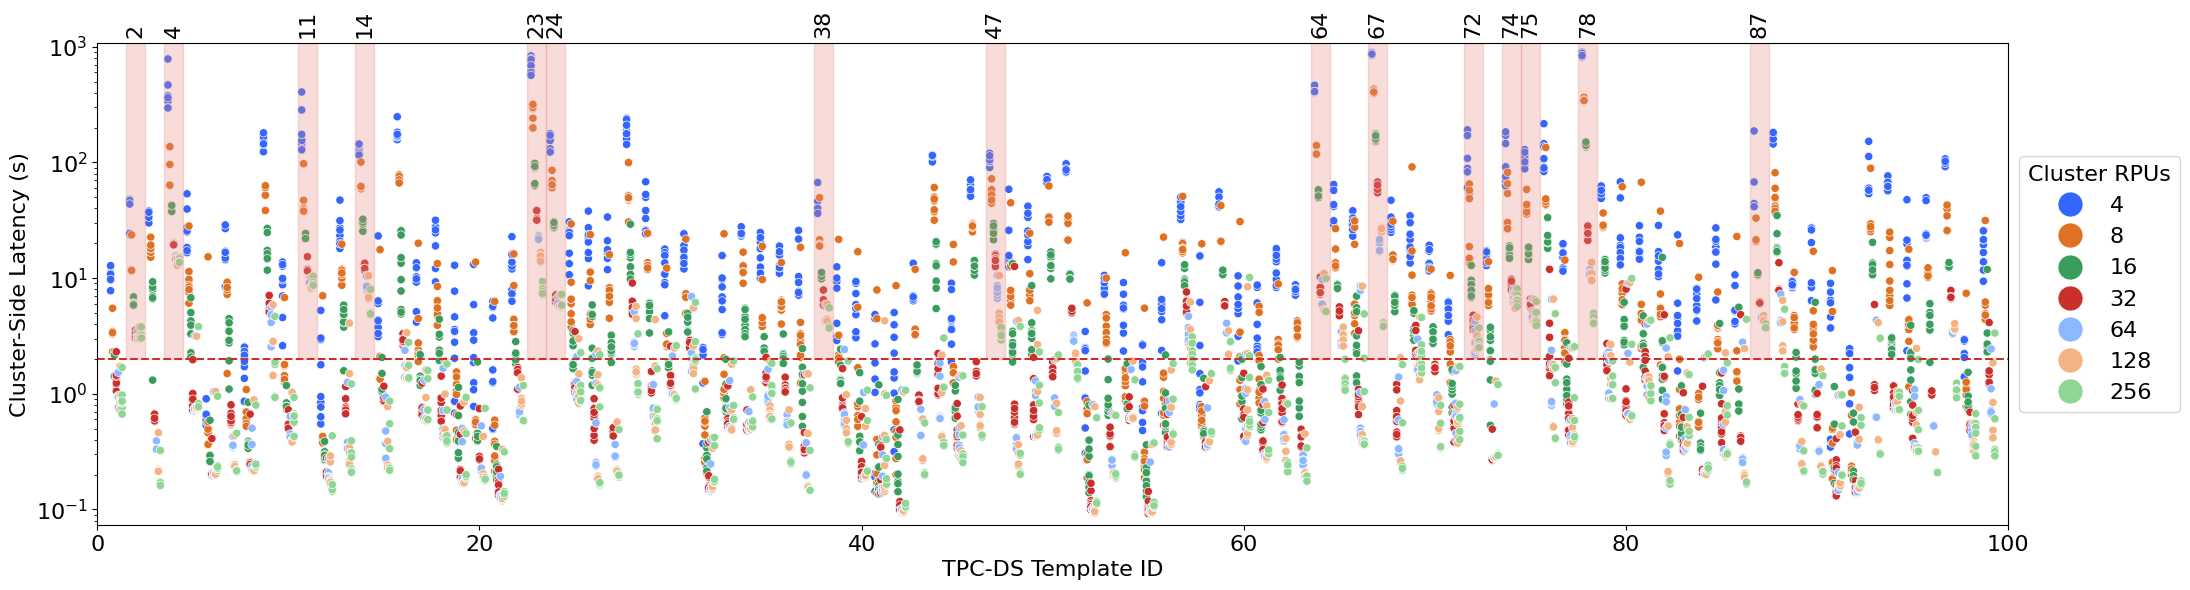

In [6]:
# Plot a grouped scatter plot, where the y axis is elapsed time in log scale. The x axis is the query template id. For each x axis value, there is a point for the mean of each endpoint, with different colors.
# Cast the endpoint names as integers and set the palette accordingly to get darker colors for higher rpu values.
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(22, 6))

possible_rpus = sorted(full_df['rpu'].unique())
rpu_to_int = {rpu: i for i, rpu in enumerate(possible_rpus)}


full_df['xpos'] = full_df['tpcds_template_id'] + full_df['rpu'].map(rpu_to_int) * 0.1 - (len(possible_rpus) - 1) * 0.1 / 2

num_unique_rpu = full_df['rpu'].nunique()
colors = Palette.as_list()[:num_unique_rpu]

fontsize = 16



# Make sure to pick a palette with distinctive enough colors.
sns.scatterplot(
    data=full_df.sort_values(by="rpu"),
    x="xpos",
    y="latency_s",
    hue="endpoint_name",
    ax=ax,
    palette=colors
)
ax.set_yscale("log")
ax.set_xlim(full_df['tpcds_template_id'].min() - 1, full_df['tpcds_template_id'].max() + 1)
y_max = full_df['latency_s'].max() * 1.2
ax.set_ylim(full_df['latency_s'].min() * 0.8, y_max)



# Draw a horizontal line at 2 seconds
ax.axhline(2, color=Palette.dark_red, linestyle='--')


# For each template where all executions are above 2 seconds, shade its area in light red. Also write the template id at the bottom of the shaded area/
templates_above_2s = full_df.groupby('tpcds_template_id').filter(lambda x: (x['latency_s'] > 2).all())['tpcds_template_id'].unique()
for template_id in templates_above_2s:
    
    ax.add_patch(Rectangle((template_id - 0.5, 2), 1, y_max - 2, color=Palette.light_red, alpha=0.3))
    ax.text(template_id, y_max*1.1, str(template_id), color='black', ha='center', va='bottom', fontsize=fontsize, rotation=90)


ax.set_ylabel("Cluster-Side Latency (s)", fontsize=fontsize)
ax.set_xlabel("TPC-DS Template ID", fontsize=fontsize)
ax.legend(title="Cluster RPUs", loc='center left', bbox_to_anchor = (1, 0.5), fontsize=fontsize, title_fontsize=fontsize, markerscale=3)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)

plt.tight_layout()
plt.savefig("heavy_hitters_scatter_4.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Save out the processed dataframe for future use.
full_df['heavy_hitter'] = full_df['tpcds_template_id'].isin(templates_above_2s)
print(f'Heavy Hitters: {[int(x) for x in sorted(templates_above_2s)]}')
full_df['light_hitter'] = full_df['tpcds_template_id'].isin(templates_below_10s)
print(f'Light Hitters: {[int(x) for x in sorted(templates_below_10s)]}')
full_df.to_parquet(os.path.join(pu.get_data_path(), "processed.parquet"))
with open(os.path.join(pu.get_data_path(), "heavy_templates.txt"), "w") as f:
    for template_id in sorted(templates_above_2s):
        f.write(f"{template_id}\n")

with open(os.path.join(pu.get_data_path(), "light_templates.txt"), "w") as f:
    for template_id in sorted(templates_below_10s):
        f.write(f"{template_id}\n")

Heavy Hitters: [2, 4, 11, 14, 23, 24, 38, 47, 64, 67, 72, 74, 75, 78, 87]
Light Hitters: [8, 12, 21, 32, 41, 42, 52, 55, 61, 63, 92, 98]


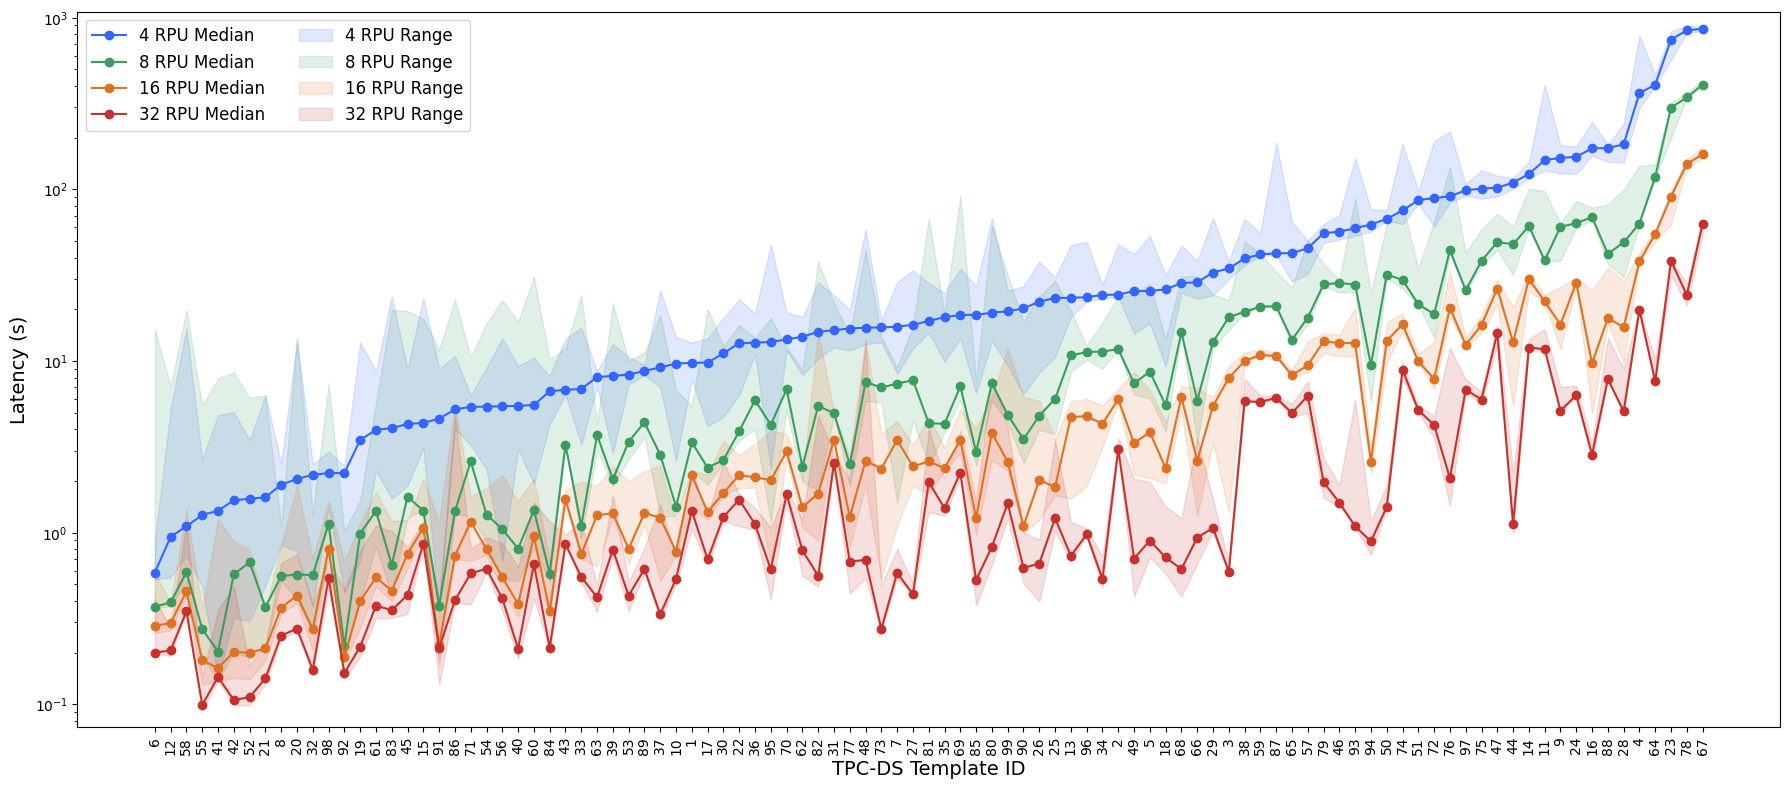

In [8]:
# Create a 2x2 grid of plots, where each is for 4, 8, 16 or 32 RPUs.
# Have each subplot be a box plot, where each box is a different query template,
# and the y axis is the latency in log scale. Order the boxes in each subplot by
# median latency, on 32 RPUs, and use the same order for all subplots. Also, use
# the same y axis limits for all subplots, and make sure they are large enough
# to show the differences between templates.

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(18, 8), sharey=True, sharex=True)

color_map = {
    4: Palette.dark_blue,
    8: Palette.dark_green,
    16: Palette.dark_orange,
    32: Palette.dark_red,
}
template_order = (
    full_df[full_df["rpu"] == 4]
    .groupby("tpcds_template_id")["latency_s"]
    .median()
    .sort_values()
    .index
)
for i, rpu in enumerate(color_map.keys()):
    subset = full_df[full_df["rpu"] == rpu]

    # Just plot the median, min and max per template as separate line plots.
    median_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .median()
        .reindex(template_order)
    )
    min_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .min()
        .reindex(template_order)
    )
    max_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .max()
        .reindex(template_order)
    )

    # Treat the template ids as categorical and plot them in the order of the
    # template_order.
    x_positions = range(len(template_order))
    ax.plot(
        x_positions,
        median_df.values,
        label=f"{rpu} RPU Median",
        color=color_map[rpu],
        marker='o',
    )
    ax.fill_between(
        x_positions,
        min_df.values,
        max_df.values,
        label=f"{rpu} RPU Range",
        color=color_map[rpu],
        alpha=0.15,
    )
ax.set_xticks(median_df.index.map(lambda x: template_order.get_loc(x)))
ax.set_xticklabels(median_df.index, rotation=90)
ax.set_xlabel("TPC-DS Template ID", fontsize=14)
ax.set_ylabel("Latency (s)", fontsize=14)
ax.set_yscale("log")

ax.set_ylim(
    full_df["latency_s"].min() * 0.8, full_df["latency_s"].max() * 1.2
)

# Reorder the legend to have the medians first, then the ranges, and make the markers bigger.
handles, labels = ax.get_legend_handles_labels()
median_idxs = [i for i in range(len(labels)) if "Median" in labels[i]]
range_idxs = [i for i in range(len(labels)) if "Range" in labels[i]]

ax.legend(
    [handles[i] for i in median_idxs] + [handles[i] for i in range_idxs],
    [labels[i] for i in median_idxs] + [labels[i] for i in range_idxs],
    loc="upper left",
    fontsize=12,
    title_fontsize=12,
    ncols=2,
)


plt.tight_layout()
plt.show()

In [17]:
all = {}

latency_bucket_edges = [0,  1, 10, 60]

for rpu in color_map.keys():
    subset = full_df[full_df["rpu"] == rpu]

    # Just plot the median, min and max per template as separate line plots.
    median_s = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .median()
        .reindex(template_order)
    )
    median_df = median_s.to_frame()
    median_df['latency_rounded_down_s'] = median_df['latency_s'].apply(lambda x: max([edge for edge in latency_bucket_edges if edge <= x]))

    all[rpu] = median_df.groupby("latency_rounded_down_s").size().to_dict()
all_df = pd.DataFrame(all).fillna(0).astype(int).sort_index()
all_df

,4,8,16,32
0,2,17,27,57
1,34,46,49,35
10,41,27,20,6
60,22,9,3,1


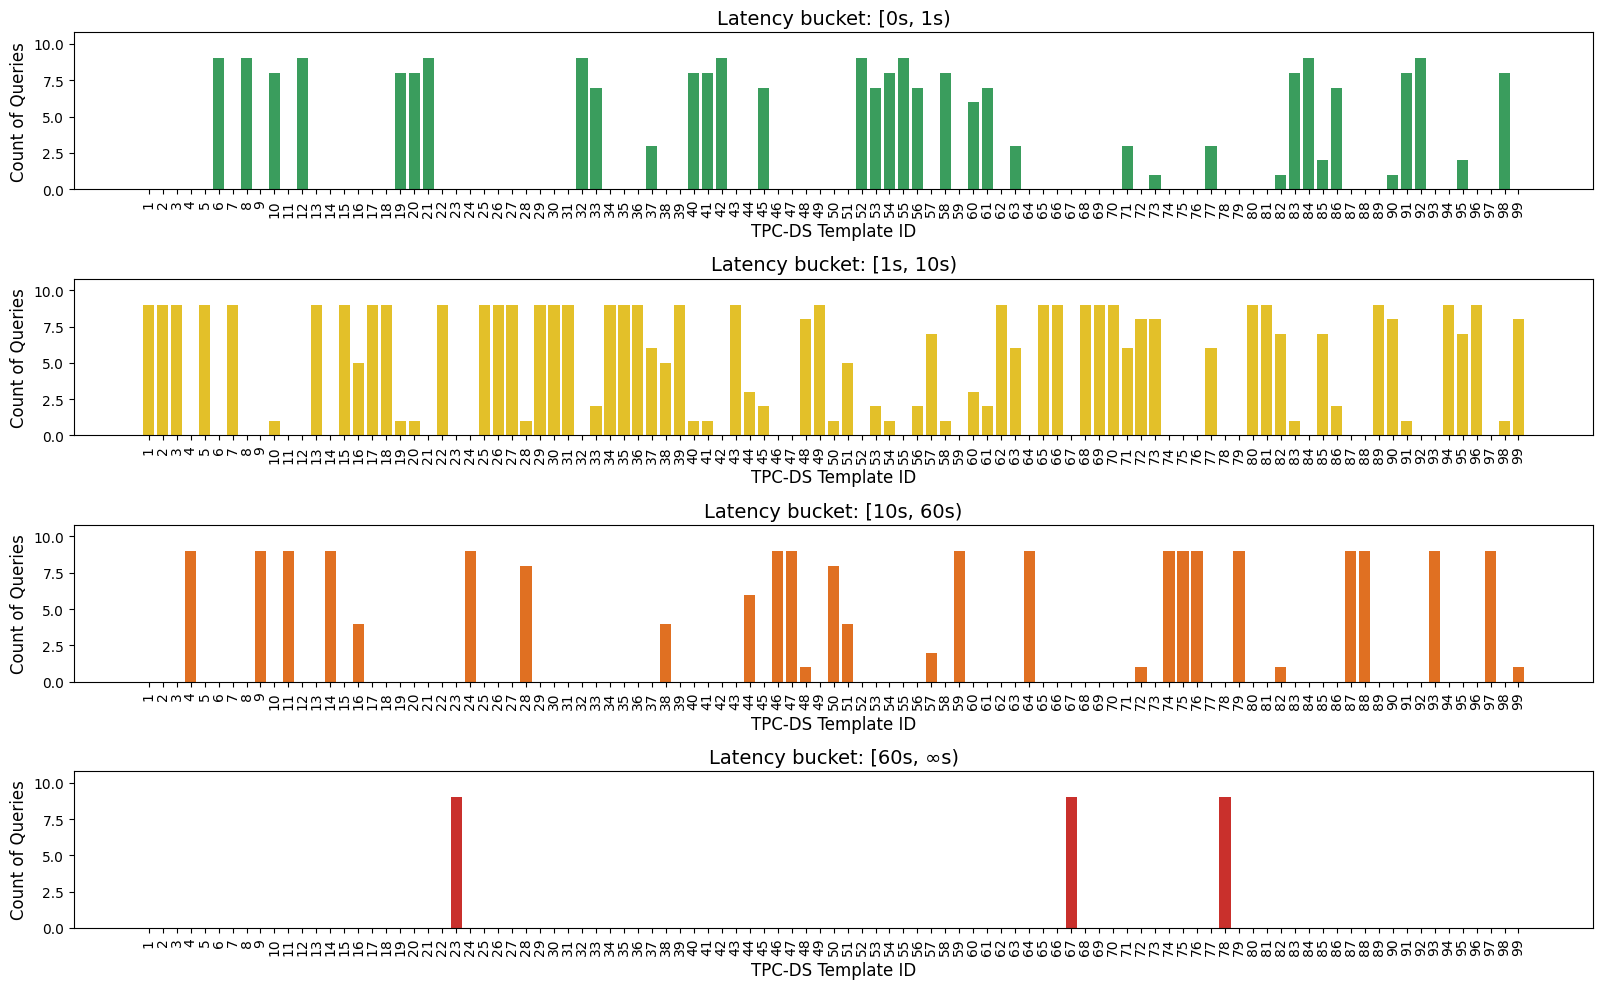

In [71]:
latency_bucket_left_edges = [0,  1, 10, 60]

full_df['latency_bucket_left_edge_s'] = full_df['latency_s'].apply(lambda x: max([edge for edge in latency_bucket_left_edges if edge <= x]))
full_df['latency_bucket_idx'] = full_df['latency_bucket_left_edge_s'].apply(lambda x: latency_bucket_left_edges.index(x))
sub_df = full_df[full_df['rpu'] == 16].copy()

# For each template and latency bucket, get the count of queries that fall into that bucket.
template_latency_counts = sub_df.groupby(['tpcds_template_id', 'latency_bucket_left_edge_s']).size().unstack(fill_value=0)
template_latency_counts

# Plot 4 subplots sharing an x axis. Each subplotis for a different bucket, 
# and the x axis is the template id. In each subplot, plot a bar for each 
# template, where the height of the bar is the count of queries that fall into 
# that bucket for that template. Use the same y axis limits for all subplots.
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(4, 1, figsize=(16, 10), sharey=True)

bucket_colors = {
    0: Palette.dark_green,
    1: Palette.dark_yellow,
    10: Palette.dark_orange,
    60: Palette.dark_red
}

for i, bucket in enumerate(latency_bucket_left_edges):
    bucket_counts = template_latency_counts[bucket]
    ax[i].bar(bucket_counts.index, bucket_counts.values, color=bucket_colors[bucket])
    right_edge = '\u221E'
    if i < len(latency_bucket_left_edges) - 1:
        right_edge = latency_bucket_left_edges[i + 1]
    
    ax[i].set_title(f"Latency bucket: [{bucket}s, {right_edge}s)", fontsize=14)
    ax[i].set_xlabel("TPC-DS Template ID", fontsize=12)
    ax[i].set_ylabel("Count of Queries", fontsize=12)
    ax[i].set_xticks(bucket_counts.index)
    ax[i].set_xticklabels(bucket_counts.index, rotation=90)
    ax[i].set_ylim(0, template_latency_counts.values.max() * 1.2)
plt.tight_layout()
plt.savefig("template_latency_buckets.svg", dpi=300)
plt.show()

/tmp/ipykernel_69846/382494522.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fraction_below_median_reference_rpu = subset.groupby("tpcds_template_id").apply(
/tmp/ipykernel_69846/382494522.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fraction_below_median_reference_rpu = subset.groupby("tpcds_template_id").apply(
/tmp/ipykernel_69846/382494522.py:93: DeprecationWarning: DataFrameGroupBy.apply

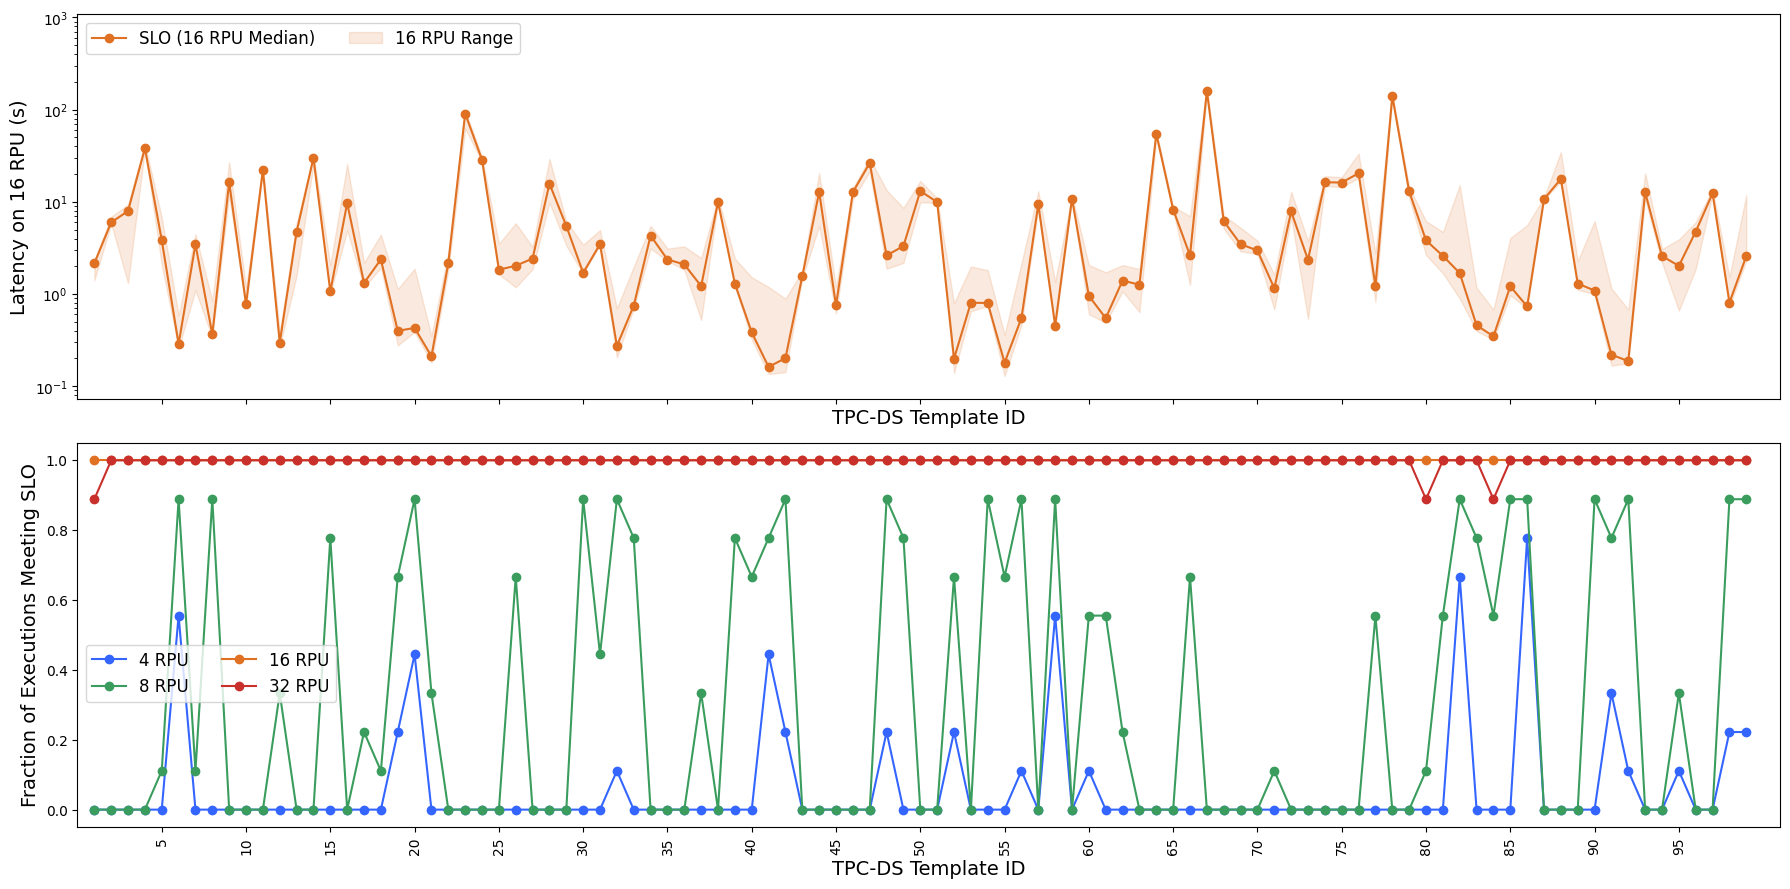

In [66]:
# Create a 2x2 grid of plots, where each is for 4, 8, 16 or 32 RPUs.
# Have each subplot be a box plot, where each box is a different query template,
# and the y axis is the latency in log scale. Order the boxes in each subplot by
# median latency, on 32 RPUs, and use the same order for all subplots. Also, use
# the same y axis limits for all subplots, and make sure they are large enough
# to show the differences between templates.

import matplotlib.pyplot as plt
import seaborn as sns

reference_rpus = 16

fig, axs = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

color_map = {
    4: Palette.dark_blue,
    8: Palette.dark_green,
    16: Palette.dark_orange,
    32: Palette.dark_red,
}
template_order = list(range(1, 100))
if True:
    ax = axs[0]
    rpu = reference_rpus
    subset = full_df[full_df["rpu"] == rpu]

    # Just plot the median, min and max per template as separate line plots.
    median_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .median()
        .reindex(template_order)
    )
    min_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .min()
        .reindex(template_order)
    )
    max_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .max()
        .reindex(template_order)
    )

    # Treat the template ids as categorical and plot them in the order of the
    # template_order.
    x_positions = range(len(template_order))
    ax.plot(
        x_positions,
        median_df.values,
        label=f"SLO ({rpu} RPU Median)",
        color=color_map[rpu],
        marker='o',
    )
    ax.fill_between(
        x_positions,
        min_df.values,
        max_df.values,
        label=f"{rpu} RPU Range",
        color=color_map[rpu],
        alpha=0.15,
    )
    # Add a tick for every 5th template id.
    ax.set_xticks([template_order.index(i) for i in template_order if i % 5 == 0])
    ax.set_xticklabels([i for i in template_order if i % 5 == 0], rotation=90)
    ax.set_xlabel("TPC-DS Template ID", fontsize=14)
    ax.set_ylabel(f"Latency on {rpu} RPU (s)", fontsize=14)
    ax.set_yscale("log")

    ax.set_ylim(
        full_df["latency_s"].min() * 0.8, full_df["latency_s"].max() * 1.2
    )
    ax.set_xlim(-1, 100)

    ax.legend(
        loc="upper left",
        fontsize=12,
        title_fontsize=12,
        ncols=2,
    )

if True:
    # For each RPU value, plot the  fraction of executions of each template that
    # take less than the median latency of that template on 8 RPUs. 
    ax = axs[1]
    rpu_to_fraction_below_median_8rpu = {}
    for rpu in color_map.keys():
        subset = full_df[full_df["rpu"] == rpu]
        median_8rpu = (
            full_df[full_df["rpu"] == reference_rpus]
            .groupby("tpcds_template_id")["latency_s"]
            .max()
        )
        fraction_below_median_reference_rpu = subset.groupby("tpcds_template_id").apply(
            lambda x: (x["latency_s"] <= median_8rpu[x.name]).mean()
        ).reindex(template_order)
        rpu_to_fraction_below_median_8rpu[rpu] = fraction_below_median_reference_rpu
        ax.plot(
            range(len(template_order)),
            fraction_below_median_reference_rpu.values,
            label=f"{rpu} RPU",
            color=color_map[rpu],
            marker='o',
        )
    ax.set_xticks([template_order.index(i) for i in template_order if i % 5 == 0])
    ax.set_xticklabels([i for i in template_order if i % 5 == 0], rotation=90)
    ax.set_xlabel("TPC-DS Template ID", fontsize=14)
    ax.set_ylabel("Fraction of Executions Meeting SLO", fontsize=14)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(0, 0.4),
        fontsize=12,
        title_fontsize=12,
        ncols=2,
    )



plt.tight_layout()
plt.savefig("slo_selection.svg", dpi=300)
plt.show()

In [70]:
slo_dict =max_df.to_dict()
# Round to 1 ms
slo_dict = {k: round(v, 3) for k, v in slo_dict.items()}

import yaml
with open(os.path.join(pu.get_data_path(), "slo_dict.yml"), "w") as f:
    yaml.dump(slo_dict, f)